# Lattice thermal conductivity κ(T) of FCC Al

Overlay of `calculate_phonon_thermal_conductivity` for four force engines on the same
Al FCC primitive cell:

| Calculator      | Where it lives                       | Notes                                     |
| --------------- | ------------------------------------ | ----------------------------------------- |
| EMT             | `ase.calculators.emt`                | Toy potential — included as a sanity baseline. |
| EAM (Zhou)      | `ase.calculators.eam` + Al .eam.alloy| Classical semi-empirical reference.       |
| GRACE-1L-OAM    | `tensorpotential` foundation model (GPU/TF) | Equivariant MLIP, single GRACE-OAM layer. |
| MACE-MP small   | `mace-torch` foundation model (GPU/torch)   | Materials-Project pretrained MACE.        |

Because GRACE (TensorFlow) and MACE (PyTorch) pull in mutually-incompatible CUDA
stacks, each calculator runs in its own conda env via a small subprocess driver
(`_kappa_driver.py`). Results are pickled and re-loaded here for plotting.


In [1]:
import json
import os
import pickle
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Worktree root is one level above the notebook
ROOT = Path.cwd()
if (ROOT / "_kappa_driver.py").is_file():
    ROOT = ROOT.parent  # notebook invoked from notebooks/
DRIVER = ROOT / "notebooks" / "_kappa_driver.py"
RUN_ROOT = ROOT / "notebooks" / "_phonon_runs"
RUN_ROOT.mkdir(exist_ok=True)
print(f"Worktree root: {ROOT}")
print(f"Driver:        {DRIVER}")
print(f"Run dir:       {RUN_ROOT}")


Worktree root: /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models
Driver:        /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_kappa_driver.py
Run dir:       /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs


In [2]:
# Each calculator runs in the env where its python deps are installed.
ENVS = {
    "emt":   "/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/bin/python",
    "eam":   "/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/bin/python",
    "grace": "/home/liger/miniforge3/envs/grace/bin/python",
    "mace":  "/home/liger/miniforge3/envs/mace/bin/python",
}

RUNS = [
    dict(label="EMT",          color="0.25",      marker="o", env="emt",
         spec={"kind": "emt"}),
    dict(label="EAM (Zhou)",   color="steelblue", marker="s", env="eam",
         spec={"kind": "eam",
               "potential": "/home/liger/lammps/potentials/Al_zhou.eam.alloy"}),
    dict(label="GRACE-1L-OAM", color="firebrick", marker="d", env="grace",
         spec={"kind": "grace", "model": "GRACE-1L-OAM"}),
    dict(label="MACE-MP small", color="seagreen", marker="^", env="mace",
         spec={"kind": "mace", "model": "small",
               "device": "cuda", "dtype": "float64"}),
]

# Shared run parameters. fc2=3**3 conventional cells = 108 atoms (good FC2 quality);
# fc3=2**3 = 32 atoms keeps symfc happy (needs >=27 atoms) and the 100-snapshot
# FC3 displacement sweep fast on foundation models.
PARAMS = dict(
    lattice_a=4.05,
    fc2_supercell=3,
    fc3_supercell=2,
    n_snapshots=100,
    q_mesh=11,
    temperatures=[100.0, 200.0, 300.0, 500.0, 700.0],
    displacement_distance=0.03,
    random_seed=42,
)
print(json.dumps(PARAMS, indent=2))


{
  "lattice_a": 4.05,
  "fc2_supercell": 3,
  "fc3_supercell": 2,
  "n_snapshots": 100,
  "q_mesh": 11,
  "temperatures": [
    100.0,
    200.0,
    300.0,
    500.0,
    700.0
  ],
  "displacement_distance": 0.03,
  "random_seed": 42
}


In [3]:
NOISE_FILTERS = (
    "oneDNN", "cpu_feature_guard", "absl::InitializeLog",
    "TF_USE_LEGACY_KERAS", "TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD",
    "cuequivariance",
)

def _slug(label):
    return label.replace(" ", "_").replace("(", "").replace(")", "")

def run_one(r):
    label = r["label"]
    pkl = RUN_ROOT / f"{_slug(label)}.pkl"
    wdir = RUN_ROOT / _slug(label)
    cmd = [
        ENVS[r["env"]], str(DRIVER),
        "--label", label,
        "--calc-spec", json.dumps(r["spec"]),
        "--out-pkl", str(pkl),
        "--working-dir", str(wdir),
        "--lattice-a", str(PARAMS["lattice_a"]),
        "--fc2-supercell", str(PARAMS["fc2_supercell"]),
        "--fc3-supercell", str(PARAMS["fc3_supercell"]),
        "--n-snapshots", str(PARAMS["n_snapshots"]),
        "--q-mesh", str(PARAMS["q_mesh"]),
        "--displacement-distance", str(PARAMS["displacement_distance"]),
        "--random-seed", str(PARAMS["random_seed"]),
        "--temperatures", *[f"{T}" for T in PARAMS["temperatures"]],
    ]
    print(f"\n=== {label}  ({Path(ENVS[r['env']]).parent.parent.name} env) ===")
    t0 = time.time()
    proc = subprocess.Popen(
        cmd, cwd=str(ROOT),
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in proc.stdout:
        if any(s in line for s in NOISE_FILTERS):
            continue
        sys.stdout.write(line)
        sys.stdout.flush()
    rc = proc.wait()
    print(f"=== {label}: rc={rc} in {time.time() - t0:.1f}s ===")
    if rc != 0:
        raise RuntimeError(f"{label} driver failed (exit {rc})")
    return pkl

pkl_paths = {r["label"]: run_one(r) for r in RUNS}



=== EMT  (test_pyiron_workflow_atomistics env) ===


[EMT] start: e0=-0.0060 eV, |F|max=2.52e-15 eV/A, fc2=3**3 (108 atoms), fc3=2**3 (32 atoms), n_snap=100


[EMT] done in 18.3s, kappa_300_diag=[6.403300558875209, 6.403300558875209, 6.403300558875209] W/(m·K), wrote /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs/EMT.pkl


=== EMT: rc=0 in 21.1s ===

=== EAM (Zhou)  (test_pyiron_workflow_atomistics env) ===


[EAM (Zhou)] start: e0=-14.3086 eV, |F|max=7.57e-16 eV/A, fc2=3**3 (108 atoms), fc3=2**3 (32 atoms), n_snap=100


...

Using Materials Project MACE for MACECalculator with /home/liger/.cache/mace/20231210mace128L0_energy_epoch249model


Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


[MACE-MP small] start: e0=-14.8383 eV, |F|max=1.13e-16 eV/A, fc2=3**3 (108 atoms), fc3=2**3 (32 atoms), n_snap=100


[MACE-MP small] done in 35.4s, kappa_300_diag=[4.574021102836584, 4.574021102836584, 4.574021102836584] W/(m·K), wrote /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs/MACE-MP_small.pkl


=== MACE-MP small: rc=0 in 54.5s ===


In [4]:
results = {}
for r in RUNS:
    with open(pkl_paths[r["label"]], "rb") as f:
        results[r["label"]] = pickle.load(f)

print(f"{'Calculator':16s} {'E0 (eV)':>10s} {'κ_300K (W/m·K)':>16s} {'elapsed (s)':>13s}")
print("-" * 60)
for r in RUNS:
    d = results[r["label"]]
    iT = list(d["temperatures"]).index(300.0)
    kappa_300 = float(np.trace(d["kappa"][iT]) / 3.0)
    print(f"{r['label']:16s} {d['energy_0']:>10.4f} {kappa_300:>16.2f} {d['elapsed_s']:>13.1f}")


Calculator          E0 (eV)   κ_300K (W/m·K)   elapsed (s)
------------------------------------------------------------
EMT                 -0.0060             6.40          18.3
EAM (Zhou)         -14.3086            28.12         138.2
GRACE-1L-OAM       -14.9851             8.72          60.1
MACE-MP small      -14.8383             4.57          35.4


## κ(T) overlay


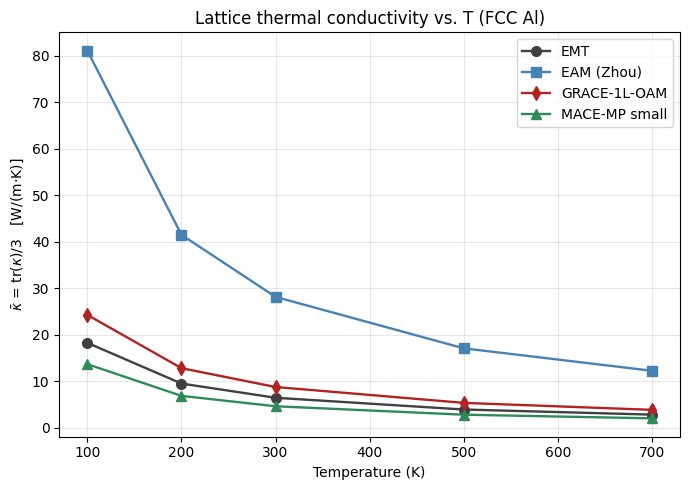

In [5]:
plt.figure(figsize=(7, 5))
for r in RUNS:
    d = results[r["label"]]
    kappa_avg = np.array([np.trace(K) / 3.0 for K in d["kappa"]])
    plt.plot(
        d["temperatures"], kappa_avg,
        color=r["color"], marker=r["marker"],
        label=r["label"], linewidth=1.7, markersize=7,
    )
plt.xlabel("Temperature (K)")
plt.ylabel(r"$\bar{\kappa}$ = tr($\kappa$)/3   [W/(m$\cdot$K)]")
plt.title("Lattice thermal conductivity vs. T (FCC Al)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Phonon band structure + DOS


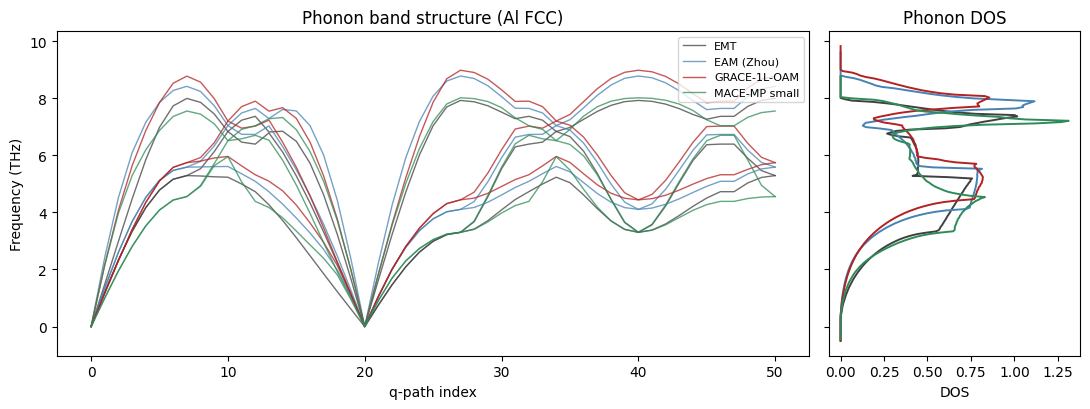

In [6]:
fig, (ax_band, ax_dos) = plt.subplots(
    1, 2, figsize=(11, 4.2),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)
for r in RUNS:
    d = results[r["label"]]
    bs = d["band_structure"]
    if bs is not None:
        freqs = bs["frequencies"]
        for branch in range(freqs.shape[1]):
            ax_band.plot(
                freqs[:, branch], color=r["color"], linewidth=1.0, alpha=0.75,
                label=r["label"] if branch == 0 else None,
            )
    dos = d["dos"]
    if dos is not None:
        ax_dos.plot(dos["dos"], dos["frequencies"], color=r["color"], linewidth=1.4,
                    label=r["label"])
ax_band.set_xlabel("q-path index")
ax_band.set_ylabel("Frequency (THz)")
ax_band.set_title("Phonon band structure (Al FCC)")
ax_band.legend(loc="upper right", fontsize=8)
ax_dos.set_xlabel("DOS")
ax_dos.set_title("Phonon DOS")
plt.tight_layout()
plt.show()


## Free energy F(T), entropy S(T), heat capacity Cv(T)


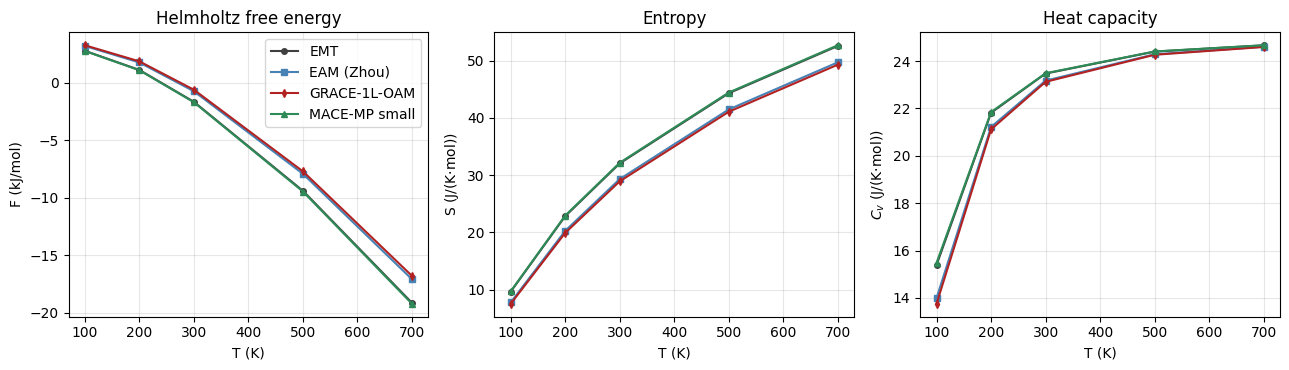

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for r in RUNS:
    d = results[r["label"]]
    fe = d["free_energy"]
    if fe is None:
        continue
    axes[0].plot(fe["temperatures"], fe["F"], color=r["color"], marker=r["marker"],
                 markersize=4, label=r["label"])
    axes[1].plot(fe["temperatures"], fe["S"], color=r["color"], marker=r["marker"],
                 markersize=4)
    axes[2].plot(fe["temperatures"], fe["Cv"], color=r["color"], marker=r["marker"],
                 markersize=4)
axes[0].set_xlabel("T (K)"); axes[0].set_ylabel("F (kJ/mol)")
axes[0].set_title("Helmholtz free energy"); axes[0].legend()
axes[1].set_xlabel("T (K)"); axes[1].set_ylabel("S (J/(K$\cdot$mol))"); axes[1].set_title("Entropy")
axes[2].set_xlabel("T (K)"); axes[2].set_ylabel(r"$C_v$ (J/(K$\cdot$mol))"); axes[2].set_title("Heat capacity")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
